In [46]:
# import the required modules

import pandas as pd
import numpy as np
#import modules for the kmeans clustering algorithmn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#load the marketing dataset 

market_df = pd.read_csv('marketing.csv')

In [4]:
#view the first few rows of the dataset
market_df.head()

,Sex,MaritalStatus,Age,Education,Occupation,YearsInSf,DualIncome,HouseholdMembers,Under18,HouseholdStatus,TypeOfHome,EthnicClass,Language,Income
0,2,1.0,5,4.0,5.0,5.0,3,3.0,0,1.0,1.0,7.0,NaN,9
1,1,1.0,5,5.0,5.0,5.0,3,5.0,2,1.0,1.0,7.0,1.0,9
2,2,5.0,1,2.0,6.0,5.0,1,4.0,2,3.0,1.0,7.0,1.0,1
3,2,5.0,1,2.0,6.0,3.0,1,4.0,2,3.0,1.0,7.0,1.0,1
4,1,1.0,6,4.0,8.0,5.0,3,2.0,0,1.0,1.0,7.0,1.0,8


In [5]:
# viwew the dimensional structure of the dataset
market_df.shape

(8905, 14)

The dataset has 14 features and 8905 instances

In [6]:
# check the critical statistical information on the dataset
market_df.describe()

,Sex,MaritalStatus,Age,Education,Occupation,YearsInSf,DualIncome,HouseholdMembers,Under18,HouseholdStatus,TypeOfHome,EthnicClass,Language,Income
count,8905.000000,8746.000000,8905.000000,8820.000000,8770.000000,8007.000000,8905.000000,8535.000000,8905.000000,8672.000000,8548.000000,8839.000000,8548.000000,8905.000000
mean,1.545761,3.033844,3.400898,3.837755,3.778677,4.196453,1.542953,2.858348,0.670298,1.841559,1.834113,5.951691,1.127866,4.904773
std,0.497930,1.810710,1.628475,1.243868,2.541332,1.227240,0.737567,1.536210,1.084999,0.744046,1.130575,1.758900,0.414892,2.775706
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,2.000000,3.000000,1.000000,4.000000,1.000000,2.000000,0.000000,1.000000,1.000000,5.000000,1.000000,2.000000
50%,2.000000,3.000000,3.000000,4.000000,4.000000,5.000000,1.000000,3.000000,0.000000,2.000000,1.000000,7.000000,1.000000,5.000000
75%,2.000000,5.000000,4.000000,5.000000,6.000000,5.000000,2.000000,4.000000,1.000000,2.000000,3.000000,7.000000,1.000000,7.000000
max,2.000000,5.000000,7.000000,6.000000,9.000000,5.000000,3.000000,9.000000,9.000000,3.000000,5.000000,8.000000,3.000000,9.000000


DATA CLEANING

In [8]:
# check for null values

check_null = market_df.isnull().sum()
print(check_null)

Sex                   0
MaritalStatus       159
Age                   0
Education            85
Occupation          135
YearsInSf           898
DualIncome            0
HouseholdMembers    370
Under18               0
HouseholdStatus     233
TypeOfHome          357
EthnicClass          66
Language            357
Income                0
dtype: int64


In [9]:
# check for missing value
missing_value = market_df.isna().sum()
print(missing_value)

Sex                   0
MaritalStatus       159
Age                   0
Education            85
Occupation          135
YearsInSf           898
DualIncome            0
HouseholdMembers    370
Under18               0
HouseholdStatus     233
TypeOfHome          357
EthnicClass          66
Language            357
Income                0
dtype: int64


In [12]:
# check for number of duplicate rows

duplicate_rows = market_df[market_df.duplicated()]
print(len(duplicate_rows))

668


In [14]:
# dropping the rows with null and missing values

market_df = market_df.dropna().reset_index(drop=True)

In [16]:
# check to see that the null values have been removed

null_values = market_df.isnull().sum()
print(null_values)

Sex                 0
MaritalStatus       0
Age                 0
Education           0
Occupation          0
YearsInSf           0
DualIncome          0
HouseholdMembers    0
Under18             0
HouseholdStatus     0
TypeOfHome          0
EthnicClass         0
Language            0
Income              0
dtype: int64


All the rows with null values have been removed as seen above


In [17]:
# remove all the duplicate values
market_df = market_df.drop_duplicates().reset_index(drop=True)

In [18]:
# reconfirm there are no duplicate values anymore
duplicates = market_df[market_df.duplicated()]
print(len(duplicates))

0


Also all duplicate rows have been removed

In [19]:
# verifiy the statistical structure of the data
market_df.shape

(6190, 14)

Exploratory Data Analysis

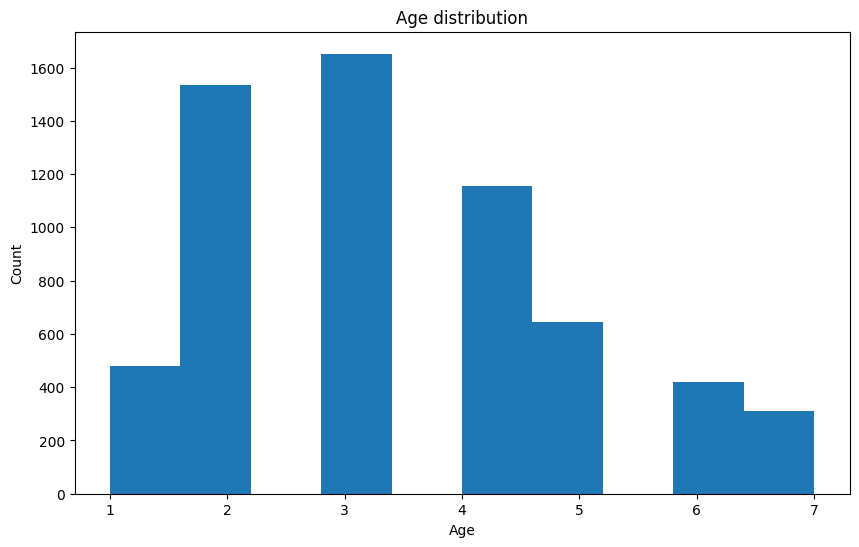

In [24]:
# plot the age distribution for the record

plt.figure(figsize=(10,6))
plt.hist(data= market_df, x= 'Age')
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

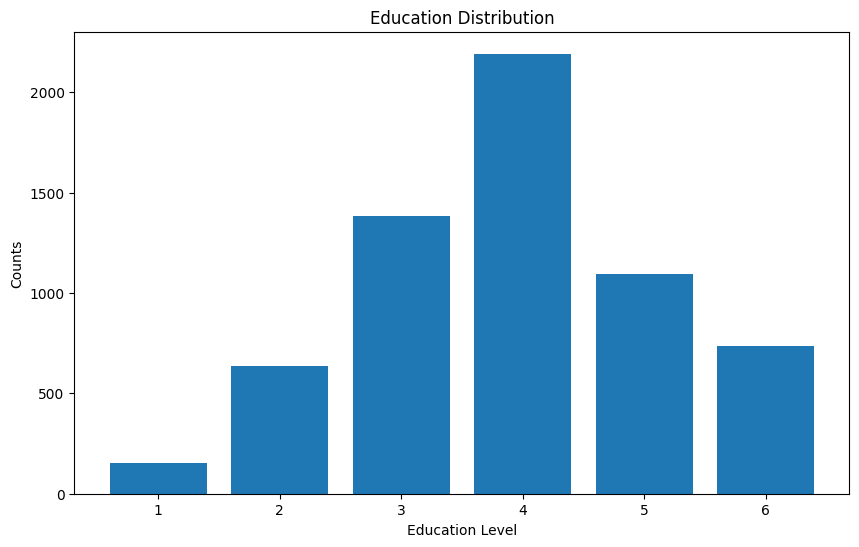

In [27]:
# plot the education distribution

education_distribution  = market_df['Education'].value_counts().sort_index()

# plot the bar chart for the distribution
plt.figure(figsize = (10,6))
plt.bar(education_distribution.index, education_distribution.values)

plt.title('Education Distribution')
plt.xlabel('Education Level')
plt.ylabel('Counts')
plt.show()

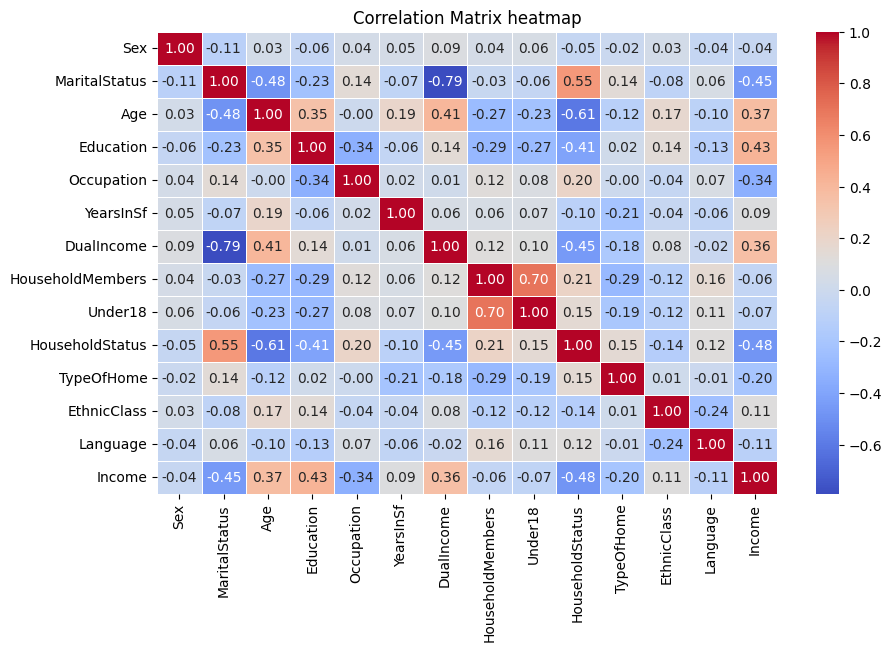

In [33]:
# plot the correlation heatmap of the correlation matrix
correlation_matrix = market_df.corr()
#plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt =".2f", linewidth = 0.5 )
plt.title('Correlation Matrix heatmap')
plt.show()

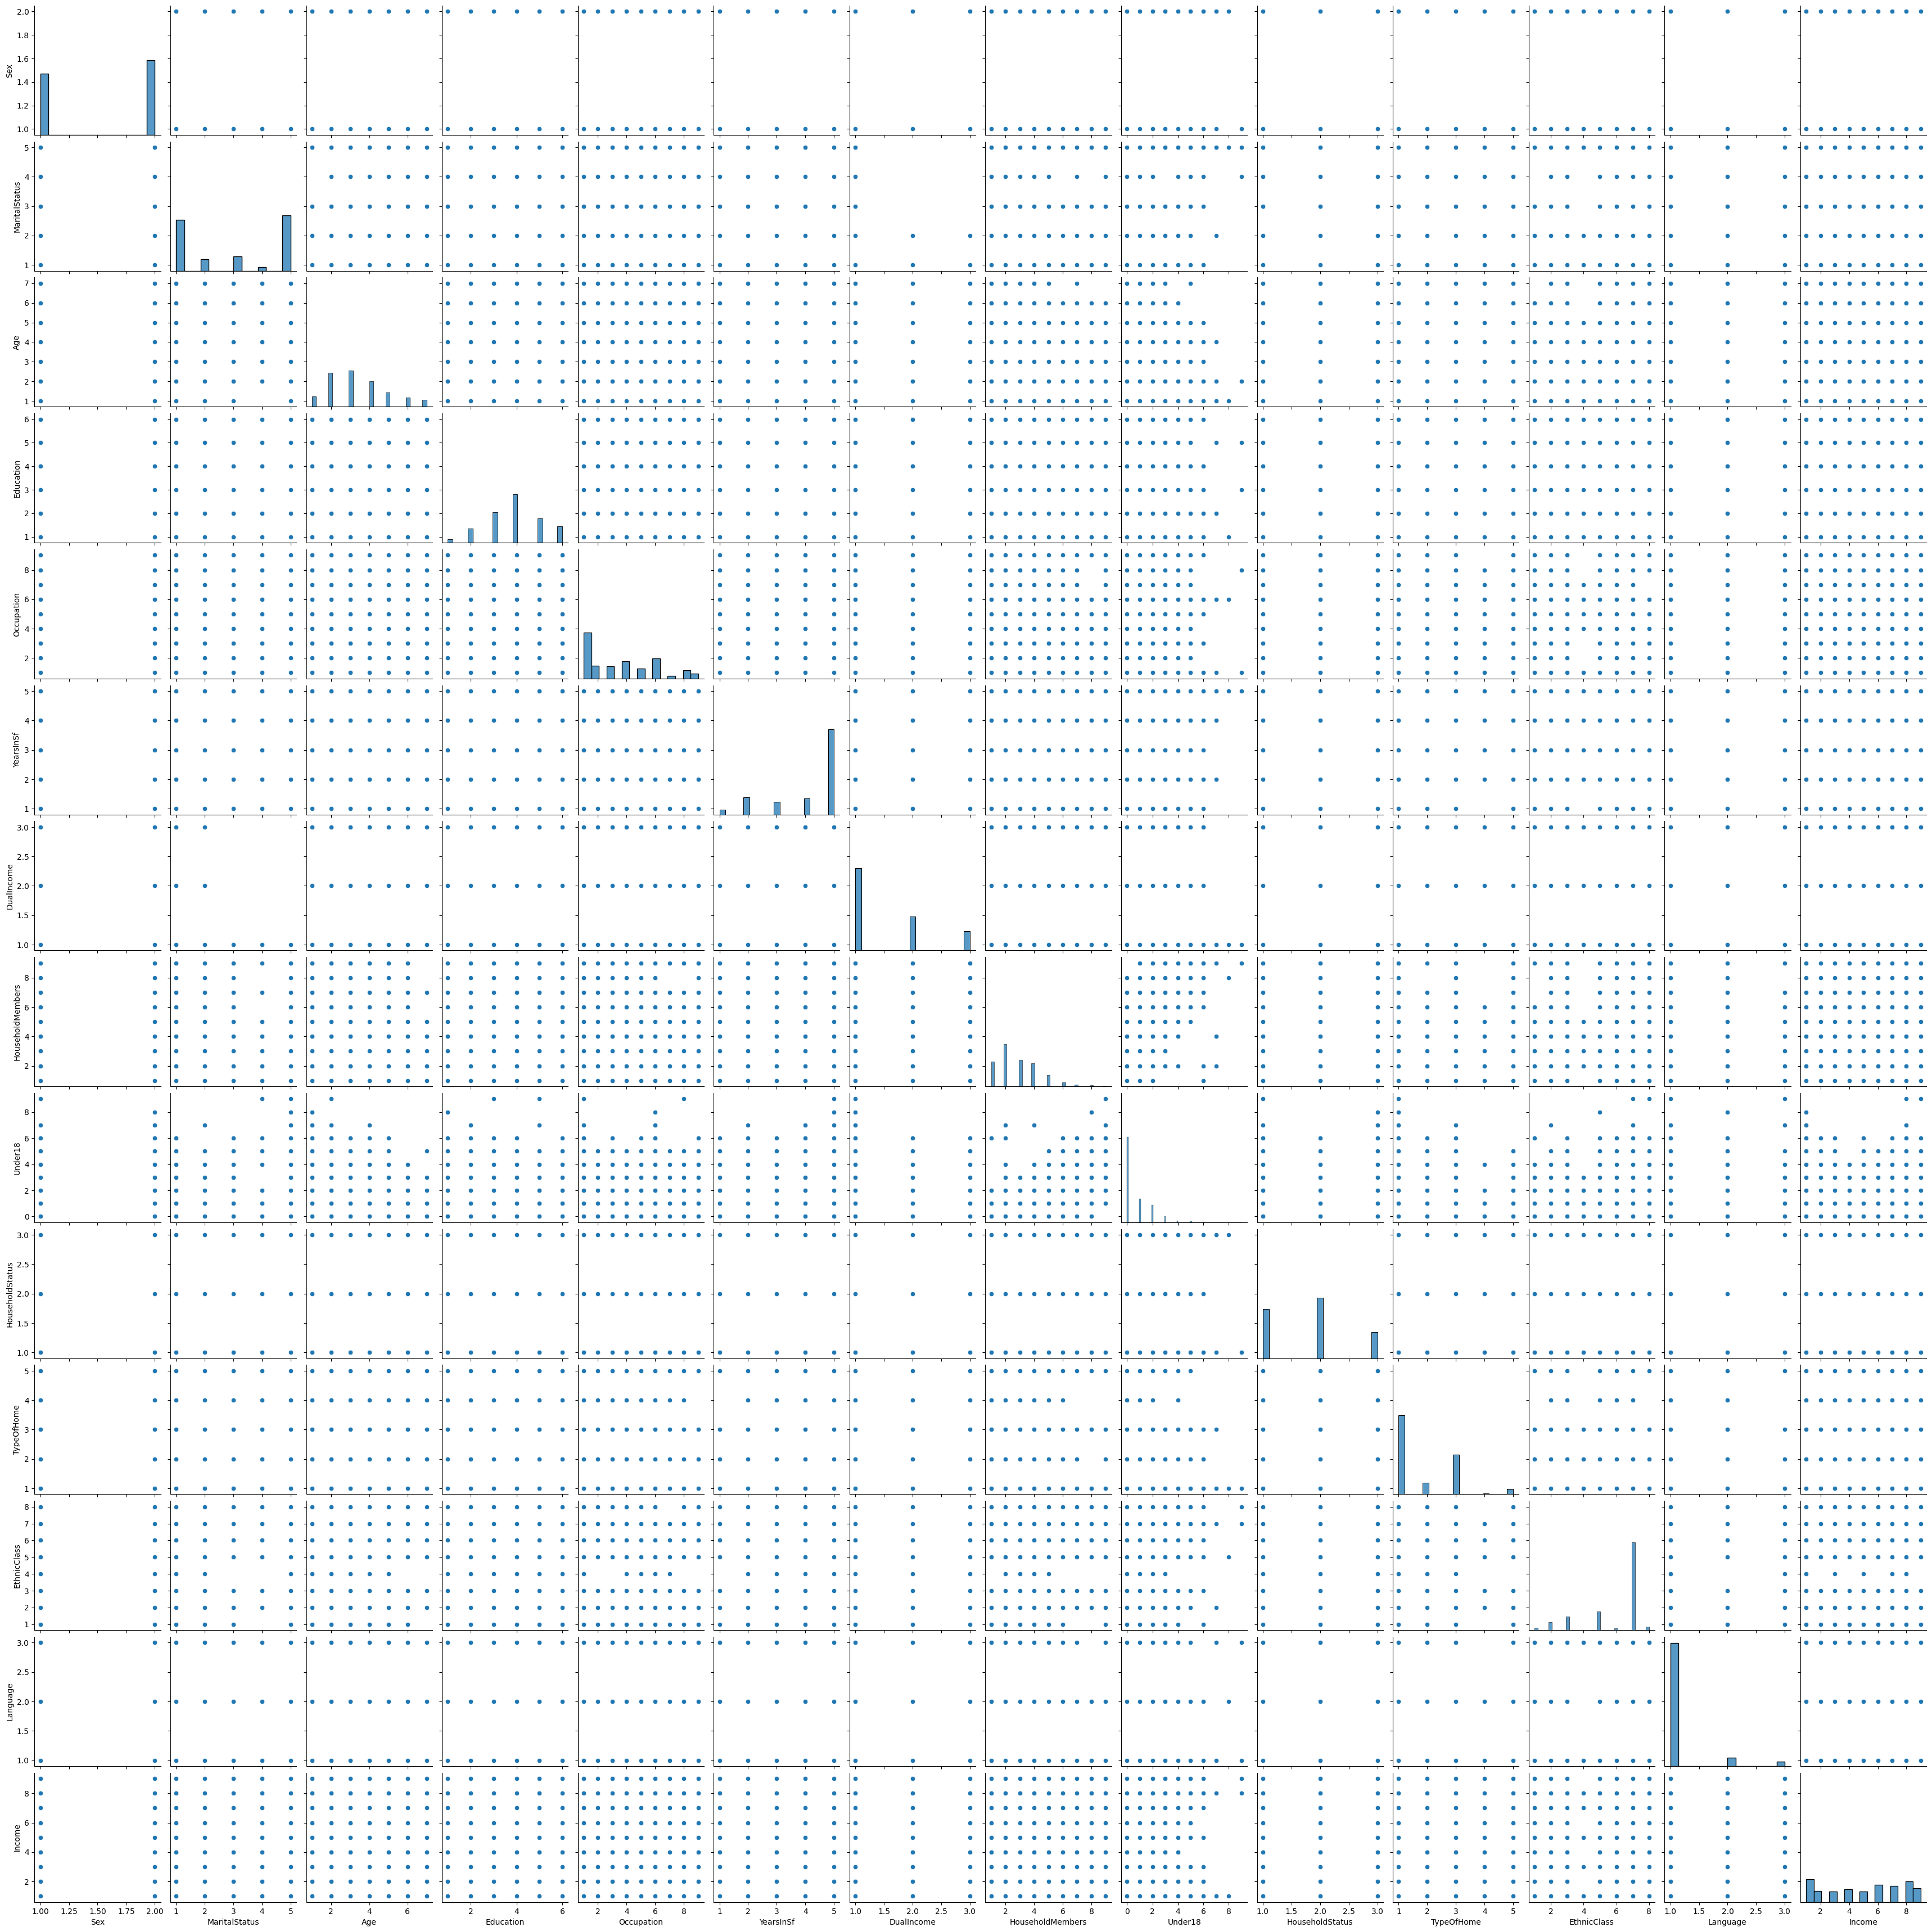

In [30]:
# plot the pairplot for the data
# represent the data as X

X = market_df
sns.pairplot(X)

Preprocessing

In [34]:
# apply standard scale to standardize the data points
scaler = StandardScaler()
X= scaler.fit_transform(X)

In [38]:
# view the first five records of the scaled X
X[0:5]

array([[-1.10355927, -1.1154387 ,  1.03278904,  0.88878444,  0.57300528,
         0.6732178 ,  2.00660275,  1.36112011,  1.2027687 , -1.14661126,
        -0.75913502,  0.59415578, -0.30340562,  1.44296207],
       [ 0.90615885,  1.1062862 , -1.54242311, -1.56362672,  0.97546785,
         0.6732178 , -0.73349675,  0.72026414,  1.2027687 ,  1.61131518,
        -0.75913502,  0.59415578, -0.30340562, -1.49143412],
       [ 0.90615885,  1.1062862 , -1.54242311, -1.56362672,  0.97546785,
        -0.94574809, -0.73349675,  0.72026414,  1.2027687 ,  1.61131518,
        -0.75913502,  0.59415578, -0.30340562, -1.49143412],
       [-1.10355927, -1.1154387 ,  1.67659208,  0.07131406,  1.780393  ,
         0.6732178 ,  2.00660275, -0.56144781, -0.62582967, -1.14661126,
        -0.75913502,  0.59415578, -0.30340562,  1.07616254],
       [-1.10355927, -0.00457625, -0.25481704,  0.07131406, -0.23191987,
         0.6732178 , -0.73349675, -1.20230379, -0.62582967,  0.23235196,
         1.03713631,  0.59

Applying K-Means

In [39]:
# PCA is used to reduce the dimensionality of the data since the features are more than 2

pca = PCA(n_components=2)

X = pca.fit_transform(X)

In [40]:
# check the variance ratio
pca.explained_variance_ratio_

array([0.24807812, 0.15587201])

In [42]:
# check the percentage of the variance

sum(pca.explained_variance_ratio_)

0.4039501291487528

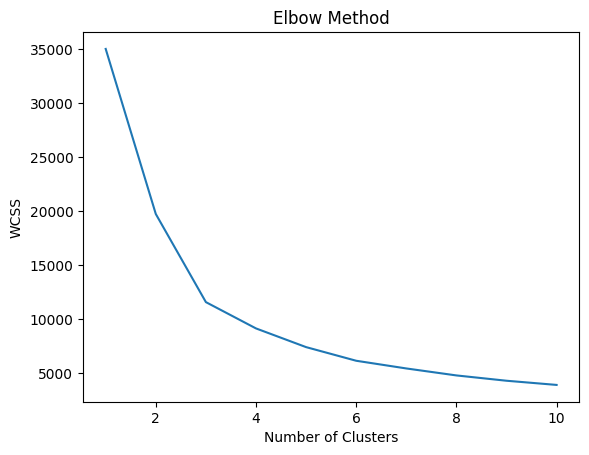

In [48]:
# using the elbow method to find the optimal numbers of clusters

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
   

The optimal number of clusters from above is seen to be n_clusters = 3

In [50]:
# fiting the K-Means to the dataset

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

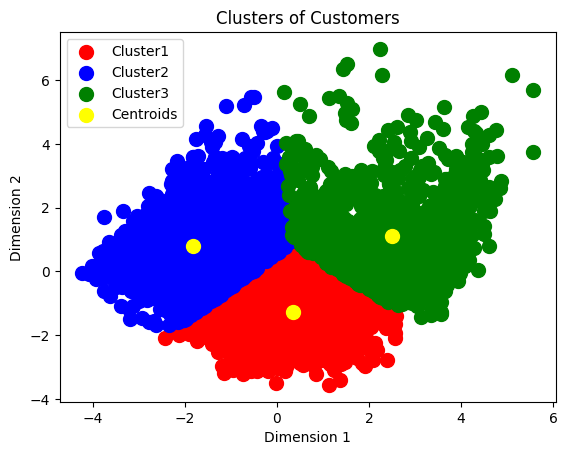

In [54]:
#plottinng the clusters

colours = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=100, c=colours[i], label = 'Cluster' + str(i+1))
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='yellow', label='Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.show()
          